In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  1000.000000  994.000000          996.000000              994.000000
mean   1499.500000   38.935614           57.149096               42.645875
std     288.819436   13.399880           28.628506               20.101589
min    1000.000000   18.000000           15.000000                1.000000
25%    1249.750000   30.000000           34.975000               31.000

In [4]:
df = df.drop_duplicates()

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,1,39.0,59.9,58.0
1,1001,1,34.0,48.4,37.0
2,1002,0,40.0,70.5,26.0
3,1003,0,47.0,81.1,30.0
4,1004,0,33.0,42.1,58.0


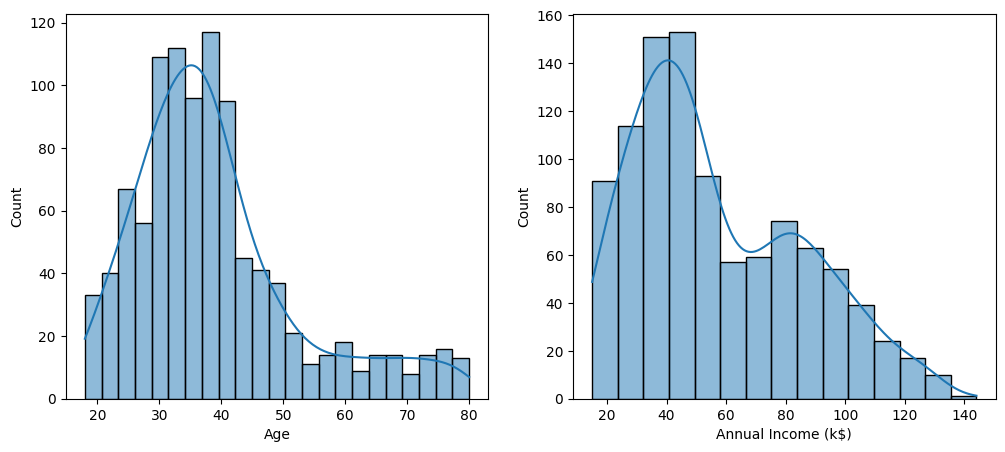

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Age"], kde=True)

plt.subplot(1,2,2)
sns.histplot(df["Annual Income (k$)"], kde=True)

plt.show()

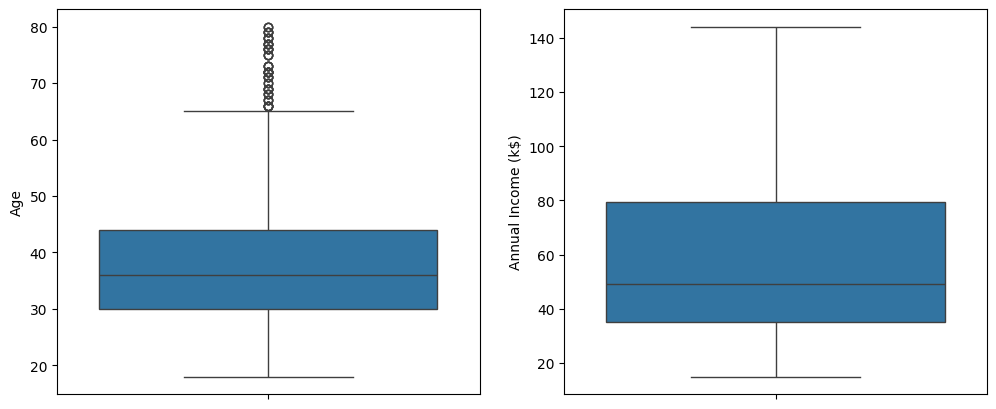

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Age"])

plt.subplot(1,2,2)
sns.boxplot(y=df["Annual Income (k$)"])

plt.show()

In [13]:
df = df.drop_duplicates()

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [14]:
X = df.drop(
    columns=["CustomerID"]
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

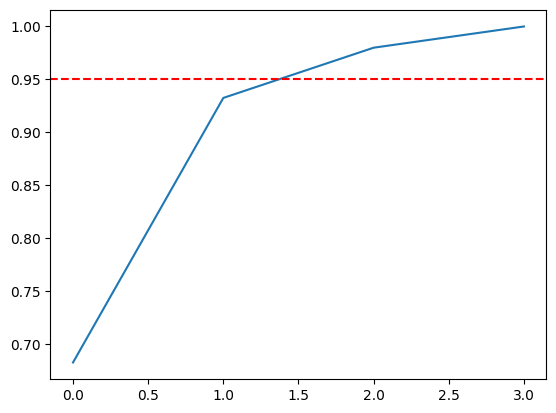

In [15]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained = np.cumsum(
    pca.explained_variance_ratio_
)

plt.plot(explained)

plt.axhline(
    y=0.95,
    color="red",
    linestyle="--"
)

plt.show()

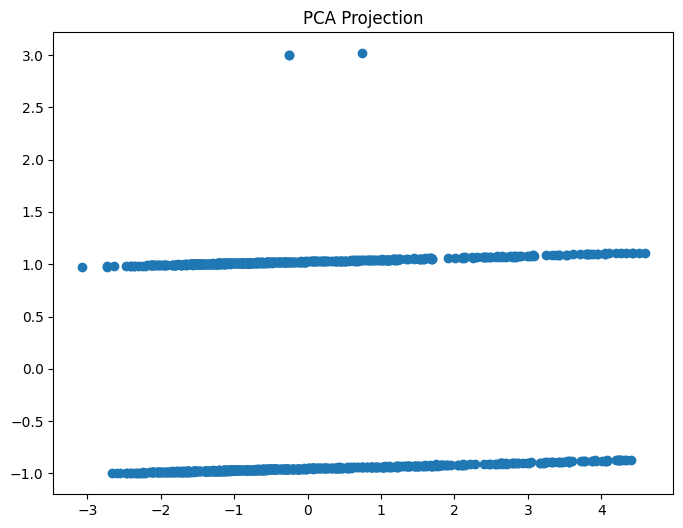

In [16]:
pca_final = PCA(
    n_components=2
)

X_2d = pca_final.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1]
)

plt.title("PCA Projection")

plt.show()

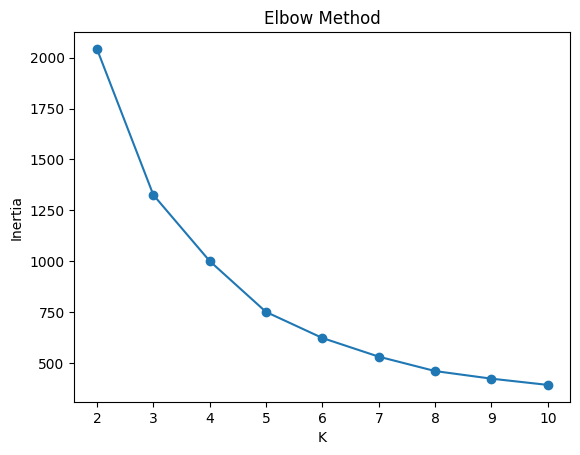

In [17]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("K")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

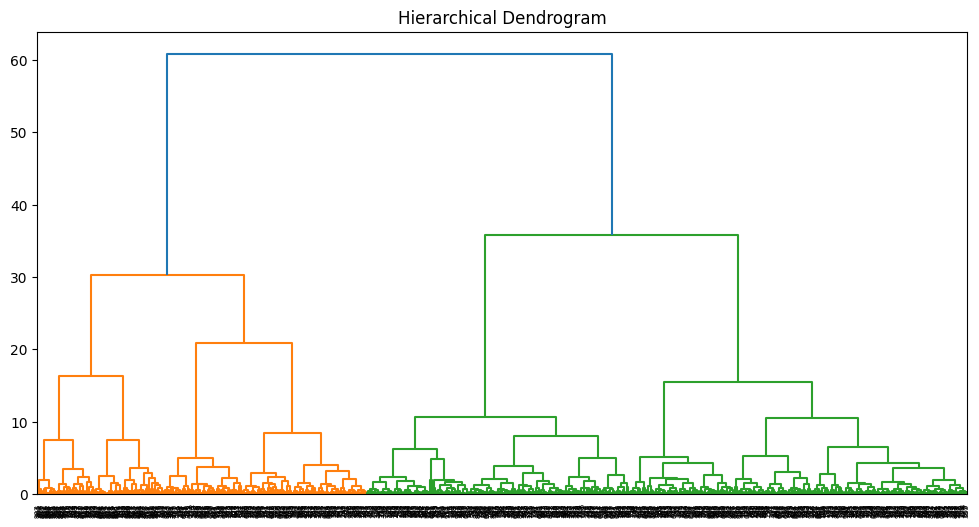

In [19]:
linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Dendrogram")

plt.show()

In [20]:
agg = AgglomerativeClustering(
    n_clusters=5
)

agg_labels = agg.fit_predict(
    X_scaled
)

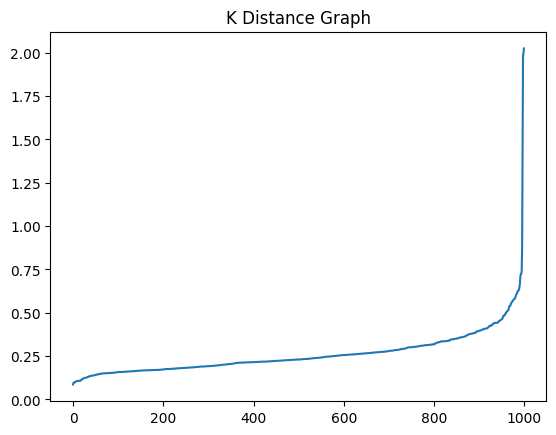

In [21]:
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(
    X_scaled
)

distances = np.sort(
    distances[:,4]
)

plt.plot(distances)

plt.title("K Distance Graph")

plt.show()

In [22]:
dbscan = DBSCAN(
    eps=1.0,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

In [23]:
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

agg_score = silhouette_score(
    X_scaled,
    agg_labels
)

valid = dbscan_labels != -1

dbscan_score = silhouette_score(
    X_scaled[valid],
    dbscan_labels[valid]
)

print("KMeans:", kmeans_score)

print("Agglomerative:", agg_score)

print("DBSCAN:", dbscan_score)

KMeans: 0.4507122145668894
Agglomerative: 0.415689029022126
DBSCAN: 0.3322084257048977


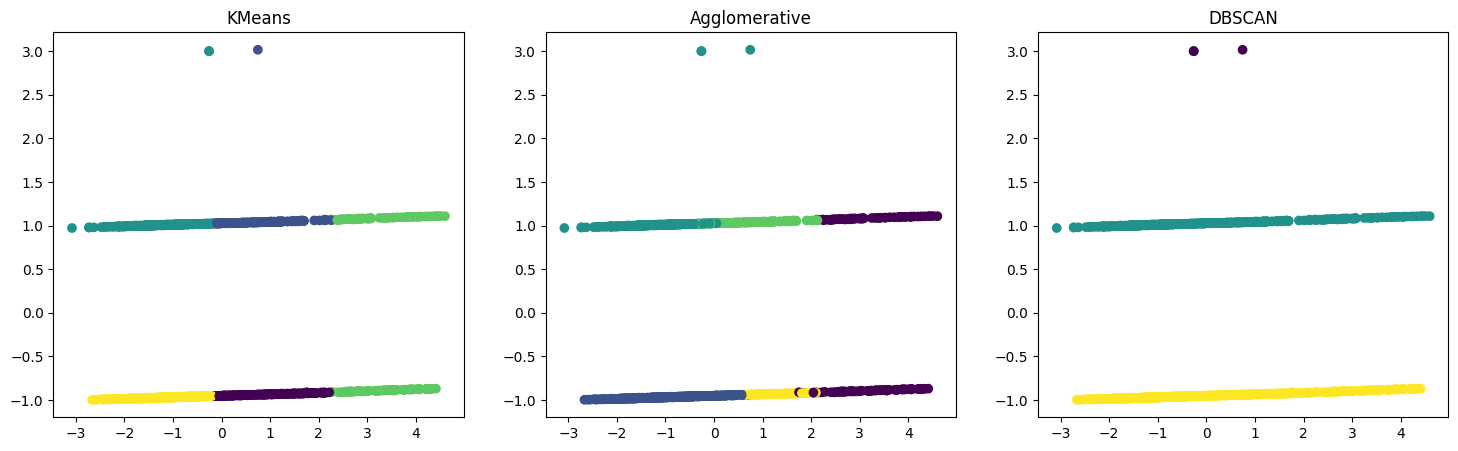

In [24]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

axes[0].scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=kmeans_labels
)

axes[0].set_title("KMeans")

axes[1].scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=agg_labels
)

axes[1].set_title("Agglomerative")

axes[2].scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=dbscan_labels
)

axes[2].set_title("DBSCAN")

plt.show()

In [25]:
summary = pd.DataFrame(
    {
        "Algorithm":[
            "KMeans",
            "Agglomerative",
            "DBSCAN"
        ],
        "Silhouette":[
            kmeans_score,
            agg_score,
            dbscan_score
        ],
        "Clusters":[
            len(np.unique(kmeans_labels)),
            len(np.unique(agg_labels)),
            len(set(dbscan_labels))-(
                1 if -1 in dbscan_labels else 0
            )
        ],
        "Noise Points":[
            0,
            0,
            np.sum(
                dbscan_labels==-1
            )
        ]
    }
)

print(summary)

       Algorithm  Silhouette  Clusters  Noise Points
0         KMeans    0.450712         5             0
1  Agglomerative    0.415689         5             0
2         DBSCAN    0.332208         2             3


In [26]:
best_algorithm = "KMeans"

df["Cluster"] = kmeans_labels

df.to_csv(
    "clustered_customers.csv",
    index=False
)

clustered = pd.read_csv(
    "clustered_customers.csv"
)

clustered.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,1,39.0,59.9,58.0,2
1,1001,1,34.0,48.4,37.0,2
2,1002,0,40.0,70.5,26.0,0
3,1003,0,47.0,81.1,30.0,0
4,1004,0,33.0,42.1,58.0,4


In [27]:
new_samples = pd.DataFrame(
    [
        [1,25,25,80],
        [0,40,80,20],
        [1,35,60,60],
        [0,22,20,95],
        [1,55,90,10]
    ],
    columns=[
        "Gender",
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

new_scaled = scaler.transform(
    new_samples
)

predicted_clusters = kmeans.predict(
    new_scaled
)

new_samples["Cluster"] = predicted_clusters

print(new_samples)

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       1   25                  25                      80        2
1       0   40                  80                      20        0
2       1   35                  60                      60        2
3       0   22                  20                      95        4
4       1   55                  90                      10        3


In [28]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

joblib.dump(
    pca_final,
    "pca_model.pkl"
)

print("Models Saved")

Models Saved


In [29]:
from google.colab import files

files.download("scaler.pkl")
files.download("kmeans_model.pkl")
files.download("pca_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>